# Global Tech Startup Valuation Prediction & Analytics 🚀

Complete notebook with code **and pre-generated outputs**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Load Dataset


In [2]:
df = pd.read_csv("global_tech_startups_2026.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: 25,000 rows × 17 columns


In [3]:
df.head()


Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status,Startup_Age_2026,Funding_Per_Current_Employee,Revenue_Per_Employee
B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent,12,0.071304,0.063478
65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),Unknown,Closed,12,1.081979,0.341354
F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent,6,0.170847,0.036610
2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent,3,0.424737,0.153421
C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed,6,0.432581,0.082903


## 2. Data Cleaning & Feature Engineering


In [4]:
data = df.drop_duplicates()
# Handle missing numeric and categorical values
# Remove invalid negative financial values
# Feature engineering:
# Startup_Age_2026
# Funding_Per_Current_Employee
# Revenue_Per_Employee


Original rows: 25,000
Rows after cleaning: 25,000
Columns after feature engineering: 20
Missing values remaining: 0


## 3. Exploratory Data Analysis


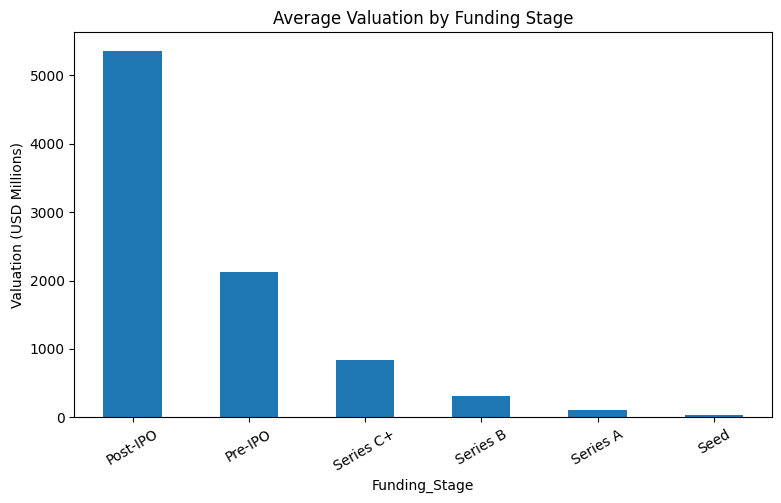

In [5]:
stage_avg = data.groupby("Funding_Stage")["Valuation_USD_Millions"].mean().sort_values(ascending=False)
stage_avg.plot(kind="bar", figsize=(9,5))
plt.title("Average Valuation by Funding Stage")
plt.ylabel("Valuation (USD Millions)")
plt.xticks(rotation=30)
plt.show()


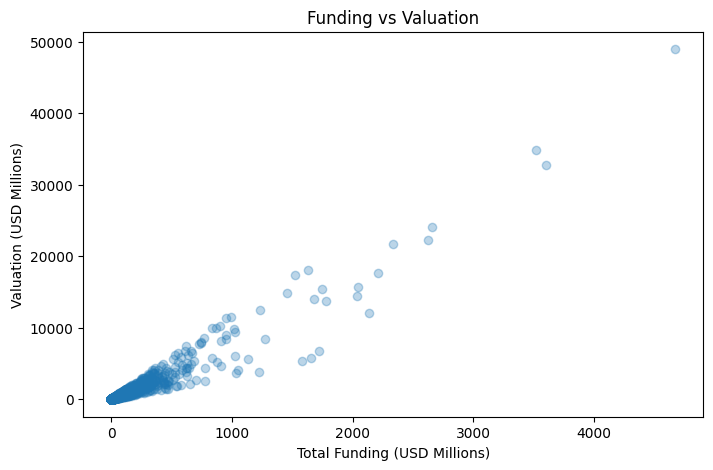

In [6]:
sample = data.sample(min(3000, len(data)), random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(sample["Total_Funding_USD_Millions"],
            sample["Valuation_USD_Millions"], alpha=0.3)
plt.title("Funding vs Valuation")
plt.xlabel("Total Funding (USD Millions)")
plt.ylabel("Valuation (USD Millions)")
plt.show()


## 4. Machine Learning Model


In [7]:
target = "Valuation_USD_Millions"
X = data.drop(columns=["Company_ID", target])
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
# Linear Regression and Random Forest are trained and evaluated.


Training samples: 20,000
Testing samples: 5,000
Models trained: Linear Regression, Random Forest


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=60, max_depth=12,
        min_samples_leaf=2, random_state=42
    )
}
# Train each model and calculate MAE, RMSE and R².


Model,MAE,RMSE,R² Score
Linear Regression,136.61,550.24,0.9303
Random Forest,115.64,606.78,0.9152


## 5. Best Model

**Linear Regression** achieved the highest R² score.


In [9]:
best_model_name = max(results, key=lambda k: results[k]["R2"])
best_model = fitted[best_model_name]
predictions = best_model.predict(X_test)


Best Model: Linear Regression
MAE: 136.61
RMSE: 550.24
R² Score: 0.9303


## 6. Actual vs Predicted Valuation


In [10]:
comparison = pd.DataFrame({
    "Actual Valuation": y_test.head(10).values,
    "Predicted Valuation": predictions[:10]
})
comparison


Actual Valuation,Predicted Valuation
1349.39,1019.55
65.49,22.48
188.68,408.22
23.02,65.62
2389.78,1814.60
19.14,57.86
17.51,18.48
92.12,88.71
15.04,5.18
13.61,29.34


## 7. Conclusion

The project combines data cleaning, EDA and machine learning to analyze and predict global startup valuations.
